# Morphology Queries

In [ ]:
import importlib.util
import sys
from pathlib import Path

# Path to your third-version parser
converter_path = Path(r"C:\Users\rahaa\Dropbox\MPCD\syntax_project\corpus\mptf_parser.py")

# Dynamically import the module
spec = importlib.util.spec_from_file_location("mptf_parser", converter_path)
mptf_parser = importlib.util.module_from_spec(spec)
sys.modules["mptf_parser"] = mptf_parser
spec.loader.exec_module(mptf_parser)

# Set input and output folders
input_folder = r"C:\Users\rahaa\Dropbox\MPCD\exports_28-1-2026"
output_folder = r"C:\Users\rahaa\Dropbox\MPCD\conllu_output"

# Convert TSV/CSV files to CoNLL-U and load as Sentence objects
corpus = mptf_parser.parse_corpus(input_folder, output_folder)

# Split into full corpus
my_corpus = corpus

# --- NEW CRITERION: sentence is syntactically annotated if it has exactly one root ---
syntactically_annotated_corpus = [
    s for s in my_corpus
    if sum(1 for t in s.get_tokens() if t.deprel == "root") == 1
]

print(f"✔ Parsed {len(my_corpus)} sentences")
print(f"✔ Syntactically annotated sentences: {len(syntactically_annotated_corpus)}")


--- Starting Corpus Parsing Pipeline ---
Step 1: Converting files from 'C:\Users\rahaa\Dropbox\MPCD\app_exports-28-1-2026'


Converting source files:   0%|          | 0/2 [00:00<?, ?it/s]


Source file conversion complete!

Step 2: Loading processed files from 'C:\Users\rahaa\Dropbox\MPCD\conllu_output'


Loading and Parsing CoNLL-U files:   0%|          | 0/48 [00:00<?, ?it/s]


Successfully loaded 40915 sentences.

--- Pipeline Complete ---
✔ Parsed 40915 sentences
✔ Syntactically annotated sentences: 5513


In [23]:
import os
from conllu import parse
from conllu.parser import DEFAULT_FIELD_PARSERS
import mptf_parser as mptf


# ======================================================
# HELPERS
# ======================================================

def clean_source_filename(filename):
    """
    Remove '_mptf' and file extension from a conllu filename.
    Example: dk4_ch22_mptf.conllu → dk4_ch22
    """
    name = os.path.splitext(filename)[0]   # remove .conllu
    if name.endswith("_mptf"):
        name = name[:-5]
    return name


# ======================================================
# LOAD BOTH CORPORA
# ======================================================

print("\n--- Loading corpora ---")

custom_field_parsers = DEFAULT_FIELD_PARSERS.copy()
custom_field_parsers["id"] = lambda line, i: line[i]
custom_field_parsers["head"] = lambda line, i: line[i]

my_corpus = []
syntactically_annotated_corpus = []

MIN_SENTENCES_SYN = 10  # threshold for syntactic corpus only

conllu_files = sorted(
    f for f in os.listdir(output_folder)
    if f.lower().endswith(".conllu")
    and "outdated" not in f.lower()
)

for filename in conllu_files:
    file_path = os.path.join(output_folder, filename)
    clean_name = clean_source_filename(filename)

    with open(file_path, "r", encoding="utf-8") as f:
        raw_data = f.read()

    # --- Clean malformed lines ---
    lines = raw_data.splitlines()
    clean_lines = [
        line for line in lines
        if line.startswith("#")
        or line.strip() == ""
        or line.count("\t") == 9
    ]
    clean_data = "\n".join(clean_lines) + "\n"

    # --- Parse sentences ---
    sentences = parse(clean_data, field_parsers=custom_field_parsers)

    # --------------------------------------------------
    # Add ALL sentences to FULL corpus
    # --------------------------------------------------
    for sent in sentences:
        sentence_obj = mptf.Sentence(
            sent,
            source_filename=clean_name
        )
        sentence_obj.metadata["source_filename"] = clean_name
        my_corpus.append(sentence_obj)

    # --------------------------------------------------
    # Add sentences to SYNTACTIC corpus only if:
    # 1. Text has ≥ MIN_SENTENCES_SYN
    # 2. Sentence has exactly one root
    # --------------------------------------------------
    if len(sentences) >= MIN_SENTENCES_SYN:
        for sent in sentences:
            sentence_obj = mptf.Sentence(
                sent,
                source_filename=clean_name
            )
            sentence_obj.metadata["source_filename"] = clean_name

            num_roots = sum(
                1 for tok in sentence_obj.get_tokens()
                if tok.deprel == "root"
            )

            if num_roots == 1:
                syntactically_annotated_corpus.append(sentence_obj)


# ======================================================
# CONFIRMATION
# ======================================================

print("✔ Corpora loaded successfully.")

print("\nmy_corpus (all texts):")
print(f"  texts:     {len(set(s.metadata['source_filename'] for s in my_corpus))}")
print(f"  sentences: {len(my_corpus)}")

print(f"\nsyntactically_annotated_corpus (≥ {MIN_SENTENCES_SYN} sentences & 1 root only):")
print(f"  texts:     {len(set(s.metadata['source_filename'] for s in syntactically_annotated_corpus))}")
print(f"  sentences: {len(syntactically_annotated_corpus)}")


# ======================================================
# SHOW CLEANED SOURCE FILENAMES
# ======================================================

annotated_files = sorted(
    set(s.metadata["source_filename"] for s in syntactically_annotated_corpus)
)

print("\n📄 Source files in the syntactically annotated corpus:")
for fname in annotated_files:
    print("-", fname)



--- Loading corpora ---
✔ Corpora loaded successfully.

my_corpus (all texts):
  texts:     42
  sentences: 35096

syntactically_annotated_corpus (≥ 10 sentences & 1 root only):
  texts:     25
  sentences: 5786

📄 Source files in the syntactically annotated corpus:
- AOD-K20
- DD-K35
- DD-TD4a
- DMX-K43a
- DMX-L19
- Dk3-B
- Dk5-B
- Dk6-B
- Dk7-B
- GA-K20
- GBd-DH
- GBd-TD1
- MHD-MHDC
- MYF-K20
- NM-K35
- NM-TD4a
- PVr-K7a
- PY-Pt4
- RThQA-TD2
- RĀF-TD2
- WZ_K35
- ZPJ̌-TD2
- ZWY-K20
- ZWY-K43a
- ŠnŠ-K20


In [24]:
#excluding texts with less than 10 sentences for this specific query
from collections import defaultdict, Counter
import csv

def export_full_pos_to_csv(corpus, output_filename):
    # --------------------------------------------------
    # storage
    # --------------------------------------------------
    text_stats = defaultdict(Counter)
    sentence_counts = Counter()

    # --------------------------------------------------
    # collect statistics
    # --------------------------------------------------
    for sentence in corpus:
        text_id = sentence.metadata.get("source_filename", "unknown")

        # count sentences per text
        sentence_counts[text_id] += 1

        for token in sentence.get_tokens():
            upos = token.upos

            # total tokens (base for density)
            if upos not in ("PUNCT", "X"):
                text_stats[text_id]["total_tokens"] += 1

            # POS categories
            if upos in {"NOUN", "PROPN"}:
                text_stats[text_id]["NOUN"] += 1
            elif upos == "PRON":
                text_stats[text_id]["PRON"] += 1
            elif upos == "ADJ":
                text_stats[text_id]["ADJ"] += 1
            elif upos == "ADV":
                text_stats[text_id]["ADV"] += 1
            elif upos == "VERB":
                text_stats[text_id]["VERB"] += 1
            elif upos == "DET":
                text_stats[text_id]["DET"] += 1

    # --------------------------------------------------
    # write CSV
    # --------------------------------------------------
    with open(output_filename, "w", encoding="utf-8", newline="") as f:
        writer = csv.writer(f)
        writer.writerow([
            "text_id",
            "sentences",
            "total_tokens",
            "NOUN",
            "PRON",
            "ADJ",
            "ADV",
            "VERB",
            "DET"
        ])

        for tid in sorted(text_stats):
            s = text_stats[tid]
            writer.writerow([
                tid,
                sentence_counts[tid],   # ← NEW COLUMN
                s["total_tokens"],
                s["NOUN"],
                s["PRON"],
                s["ADJ"],
                s["ADV"],
                s["VERB"],
                s["DET"]
            ])


export_full_pos_to_csv(my_corpus, "total_corpus_full_pos.csv")
export_full_pos_to_csv(syntactically_annotated_corpus, "syn_corpus_full_pos.csv")
print("✔ CSV files exported successfully.")

✔ CSV files exported successfully.


In [25]:
# check if a file is included in the corpus or not

def report_syntactic_status_with_ids(source_filename, full_corpus, syntactic_corpus):
    """
    Checks the given source_filename in full and syntactically annotated corpora.

    Prints:
    - File does not exist
    - No syntactically annotated sentences
    - Or number of annotated sentences with their sentence IDs
    """
    # Check if the file exists in the full corpus
    exists_in_full = any(s.metadata.get("source_filename") == source_filename for s in full_corpus)
    
    if not exists_in_full:
        print(f"❌ File '{source_filename}' does not exist in the corpus.")
        return []

    # Filter sentences from syntactically annotated corpus
    annotated_sentences = [
        s for s in syntactic_corpus
        if s.metadata.get("source_filename") == source_filename
    ]

    if not annotated_sentences:
        print(f"⚠️ File '{source_filename}' exists but has no syntactically annotated sentences.")
        return []

    # File exists and has annotated sentences
    print(f"✅ File '{source_filename}' has {len(annotated_sentences)} syntactically annotated sentences.")
    
    # Get sentence IDs
    sentence_ids = [s.metadata.get("text", i) for i, s in enumerate(annotated_sentences)]
    print("Sentence IDs:", sentence_ids)

    return sentence_ids


# ============================
# Example usage
# ============================
source_file = "Dk4-B_mptf.conllu"  # Replace with your filename
annotated_ids = report_syntactic_status_with_ids(source_file, my_corpus, syntactically_annotated_corpus)




❌ File 'Dk4-B_mptf.conllu' does not exist in the corpus.


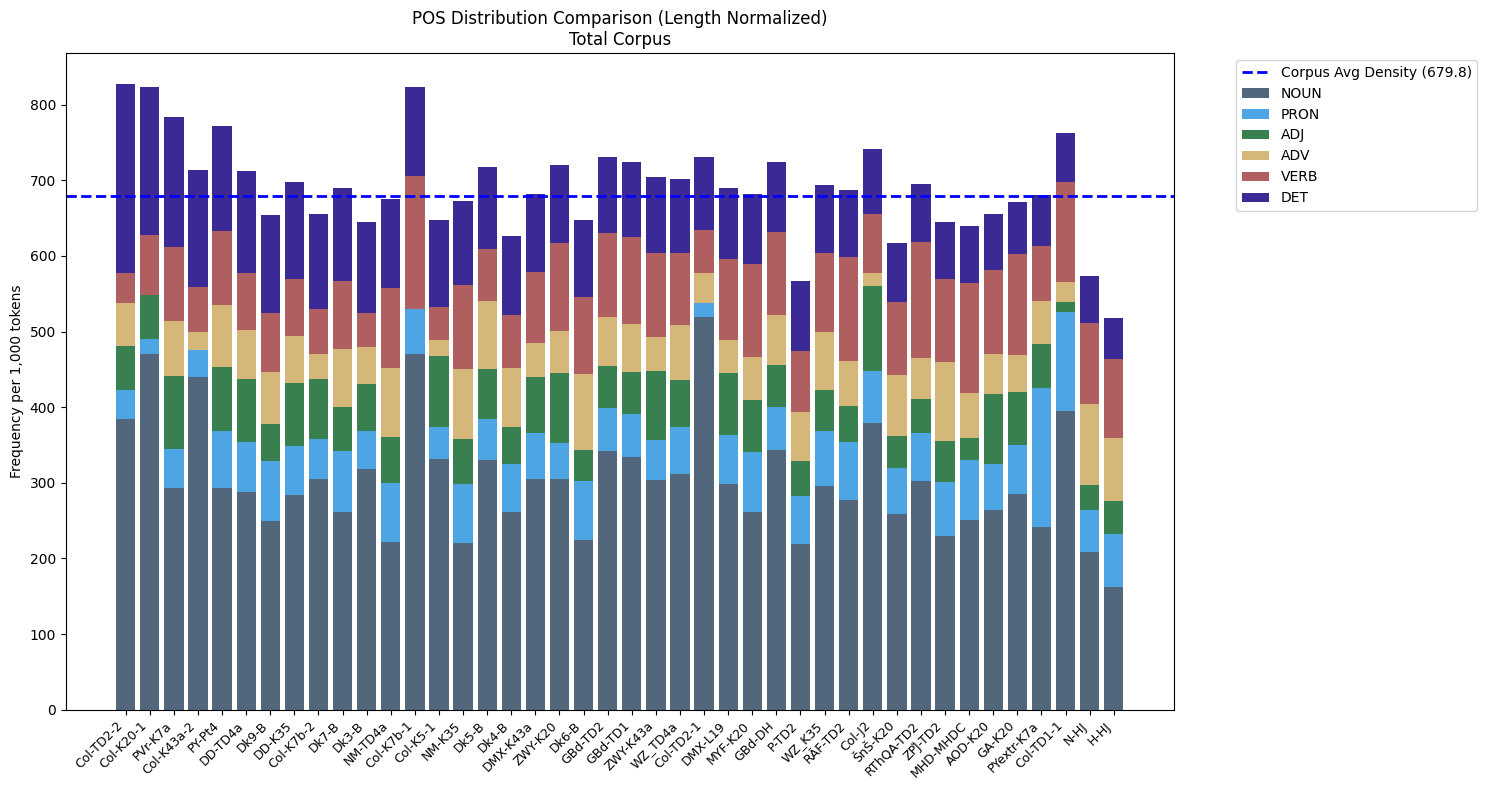

In [26]:

import pandas as pd
import matplotlib.pyplot as plt

def plot_multi_pos(csv_file, title):
    # 1. Load data
    df = pd.read_csv(csv_file)
    
    # 2. Normalize all counts per 1,000 tokens
    categories = ["NOUN", "PRON", "ADJ", "ADV", "VERB", "DET"]
    for cat in categories:
        df[f"{cat}_1k"] = (df[cat] / df["total_tokens"]) * 1000

    total_content_words = df[categories].sum().sum()
    total_corpus_tokens = df["total_tokens"].sum()
    corpus_avg_density = (total_content_words / total_corpus_tokens) * 1000


    # 3. SORT the dataframe
    df = df.sort_values("DET_1k", ascending=False)

    # --- THE CRITICAL FIX ---
    # We must reset the index so the bars and the 'bottom' alignment match perfectly
    df = df.reset_index(drop=True)
    # ------------------------

    # 4. Plotting
    x = range(len(df))
    plt.figure(figsize=(15, 8))

    # Initialize the bottom of the stack at zero for every bar
    # Using a simple list/array ensures no index mismatch
    current_bottom = [0.0] * len(df)
    
    colors = ["#40566e", "#3a9be0", "#23723E", "#d1b16a", "#a64d4d", "#25138B"]    
    for cat, color in zip(categories, colors):
        val_col = f"{cat}_1k"
        values = df[val_col].tolist() # Convert to list to be safe
        
        plt.bar(x, values, bottom=current_bottom, label=cat, color=color, alpha=0.9)
        
        # Update the bottom for the next category
        current_bottom = [b + v for b, v in zip(current_bottom, values)]
        
    plt.axhline(y=corpus_avg_density, color='blue', linestyle='--', linewidth=2, 
            label=f"Corpus Avg Density ({corpus_avg_density:.1f})")

    # 5. Formatting
    plt.xticks(x, df["text_id"], rotation=45, ha="right", fontsize=9)
    plt.ylabel("Frequency per 1,000 tokens")
    plt.title(f"POS Distribution Comparison (Length Normalized)\n{title}")
    
    
    # Place legend outside the plot
    plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1))
    
    plt.tight_layout()
    plt.show()

# Run the plots again
plot_multi_pos("total_corpus_full_pos.csv", "Total Corpus")
# plot_multi_pos("syn_corpus_full_pos_clean.csv", "Syntactic Corpus")

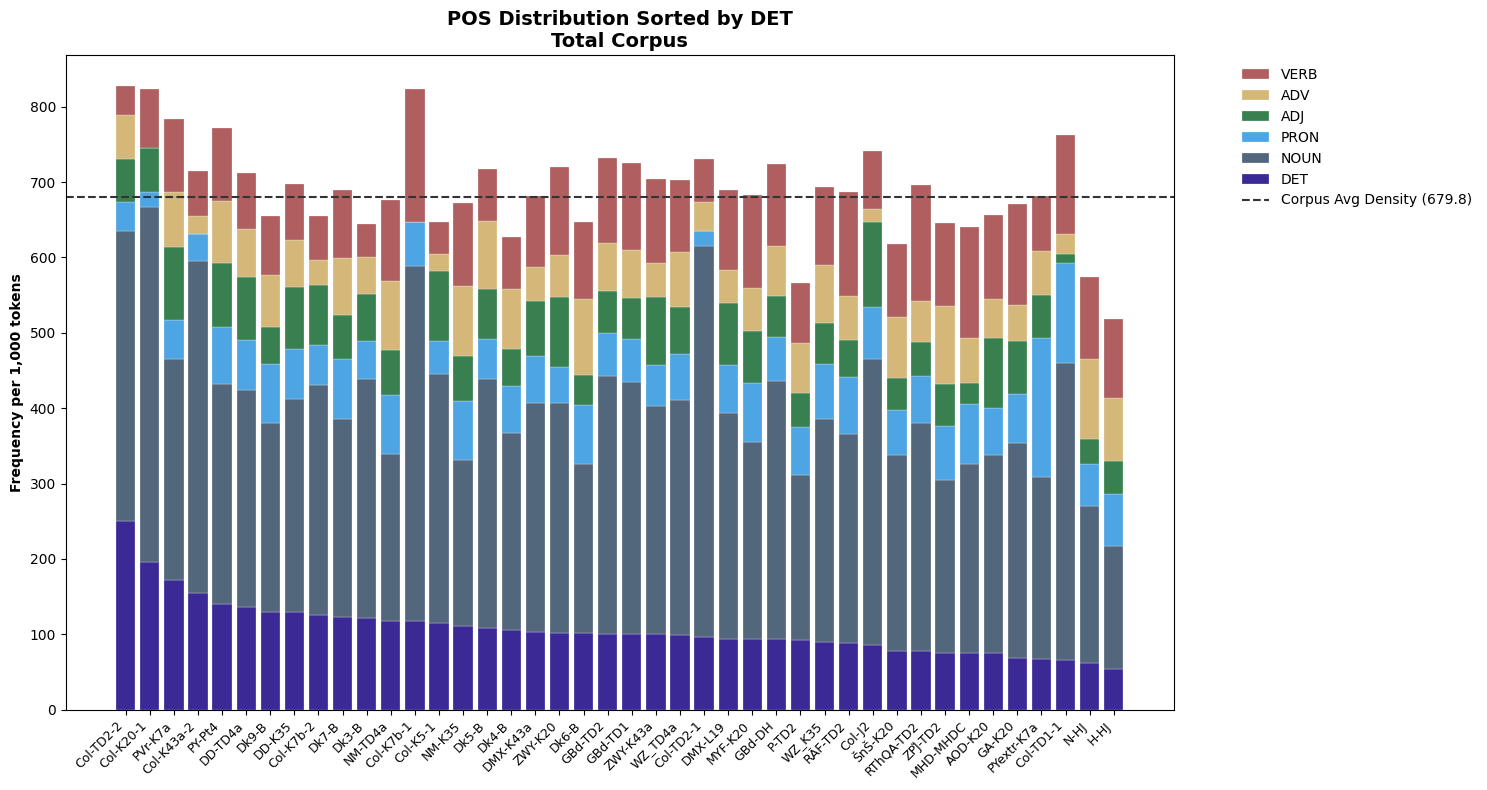

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_multi_pos(csv_file, title):
    # 1. Load data
    df = pd.read_csv(csv_file)
    
    # --- CONFIGURATION ---
    # Choose which category to sort by
    sort_standard = "DET" 
    
    # Original list of categories
    all_categories = ["NOUN", "PRON", "ADJ", "ADV", "VERB", "DET"]
    
    # Reorder categories so the sorting standard is FIRST (at the bottom of the stack)
    categories = [sort_standard] + [c for c in all_categories if c != sort_standard]
    
    # Map colors to names so they stay consistent even when we reorder
    color_map = {
        "NOUN": "#40566e",
        "PRON": "#3a9be0",
        "ADJ":   "#23723E",
        "ADV":   "#d1b16a",
        "VERB":  "#a64d4d",
        "DET":   "#25138B"
    }
    plot_colors = [color_map[cat] for cat in categories]
    # ---------------------

    # 2. Normalize
    for cat in categories:
        df[f"{cat}_1k"] = (df[cat] / df["total_tokens"]) * 1000

    # Stats for Avg Line
    total_content_words = df[all_categories].sum().sum()
    total_corpus_tokens = df["total_tokens"].sum()
    corpus_avg_density = (total_content_words / total_corpus_tokens) * 1000

    # 3. SORT by the chosen standard
    df = df.sort_values(f"{sort_standard}_1k", ascending=False).reset_index(drop=True)

    # 4. Plotting
    x = range(len(df))
    plt.figure(figsize=(15, 8))

    current_bottom = [0.0] * len(df)
    
    for cat, color in zip(categories, plot_colors):
        val_col = f"{cat}_1k"
        values = df[val_col].tolist()
        
        plt.bar(x, values, bottom=current_bottom, label=cat, color=color, alpha=0.9, edgecolor='white', linewidth=0.2)
        
        # Update the bottom for the next category
        current_bottom = [b + v for b, v in zip(current_bottom, values)]
        
    # Average line
    plt.axhline(y=corpus_avg_density, color='#333333', linestyle='--', linewidth=1.5, 
                label=f"Corpus Avg Density ({corpus_avg_density:.1f})")

    # 5. Formatting
    plt.xticks(x, df["text_id"], rotation=45, ha="right", fontsize=9)
    plt.ylabel("Frequency per 1,000 tokens", fontweight='bold')
    plt.title(f"POS Distribution Sorted by {sort_standard}\n{title}", fontsize=14, fontweight='bold')
    
    # Legend - reverse the order so it matches the visual stack
    handles, labels = plt.gca().get_legend_handles_labels()
    plt.legend(reversed(handles), reversed(labels), loc='upper left', bbox_to_anchor=(1.05, 1), frameon=False)
    
    plt.tight_layout()
    plt.show()

# Run the plot
plot_multi_pos("total_corpus_full_pos.csv", "Total Corpus")

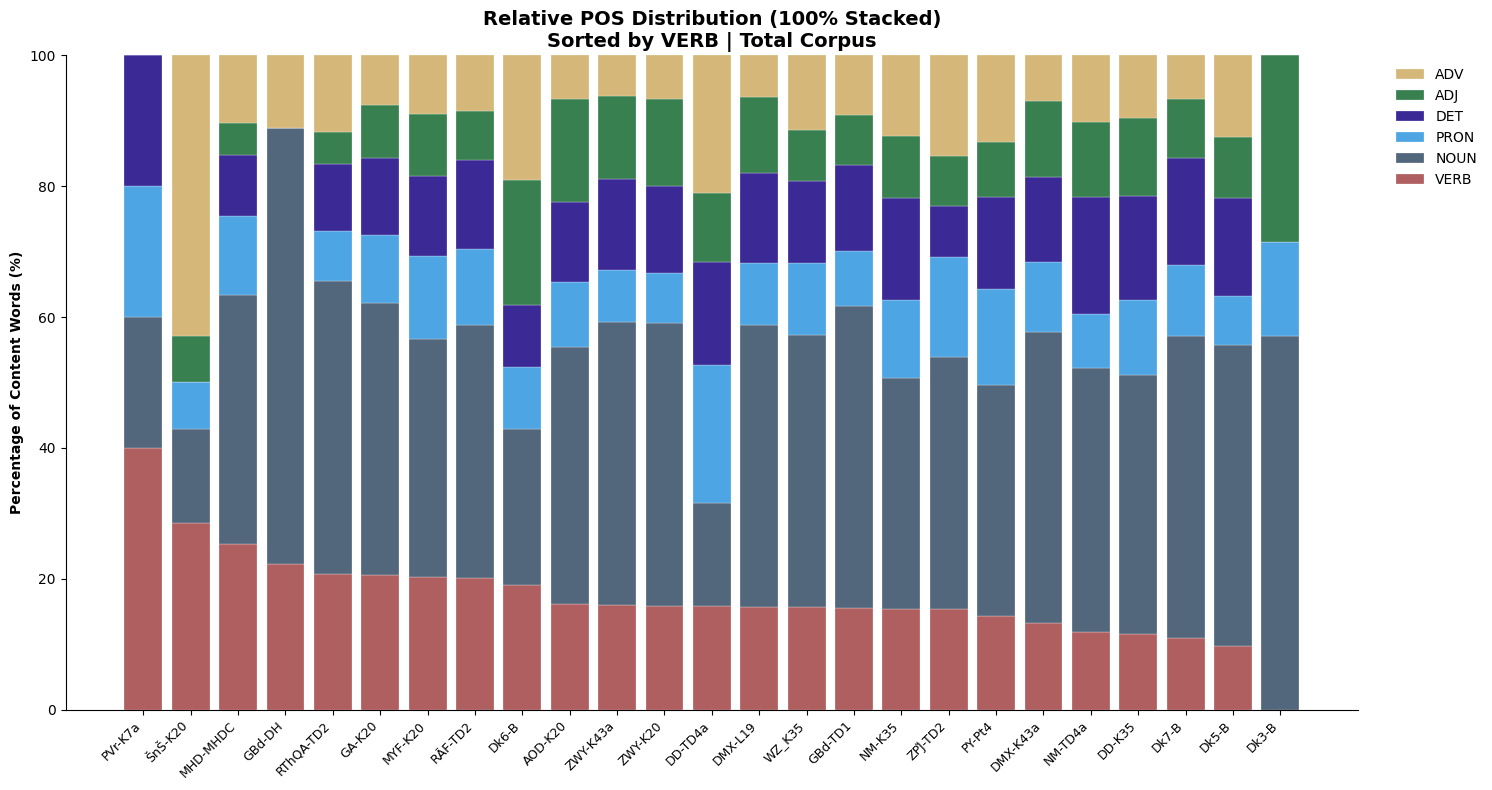

In [28]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_100pct_pos(csv_file, title):
    # 1. Load data
    df = pd.read_csv(csv_file)
    
    # --- CONFIGURATION ---
    sort_standard = "VERB" 
    all_categories = ["NOUN", "PRON", "DET", "ADJ", "ADV", "VERB"]
    
    # Reorder so sort_standard is at the bottom (index 0)
    categories = [sort_standard] + [c for c in all_categories if c != sort_standard]
    
    color_map = {
        "NOUN": "#40566e",
        "PRON": "#3a9be0",
        "DET":   "#25138B",
        "ADJ":   "#23723E",
        "ADV":   "#d1b16a",
        "VERB":  "#a64d4d"
    }
    plot_colors = [color_map[cat] for cat in categories]
    # ---------------------

    # 2. CALCULATE 100% RELATIVE SHARES
    # Sum only the categories we are interested in
    df['content_sum'] = df[all_categories].sum(axis=1)
    
    for cat in all_categories:
        # Calculate percentage: (count / sum of these 6) * 100
        df[f"{cat}_pct"] = (df[cat] / df['content_sum']) * 100

    # 3. SORT by the percentage of the chosen standard
    df = df.sort_values(f"{sort_standard}_pct", ascending=False).reset_index(drop=True)

    # 4. Plotting
    x = range(len(df))
    plt.figure(figsize=(15, 8))

    current_bottom = [0.0] * len(df)
    
    for cat, color in zip(categories, plot_colors):
        val_col = f"{cat}_pct"
        values = df[val_col].tolist()
        
        plt.bar(x, values, bottom=current_bottom, label=cat, color=color, 
                alpha=0.9, edgecolor='white', linewidth=0.2)
        
        current_bottom = [b + v for b, v in zip(current_bottom, values)]
        
    # 5. Formatting
    plt.xticks(x, df["text_id"], rotation=45, ha="right", fontsize=9)
    plt.ylabel("Percentage of Content Words (%)", fontweight='bold')
    plt.ylim(0, 100) # Always 0 to 100
    
    plt.title(f"Relative POS Distribution (100% Stacked)\nSorted by {sort_standard} | {title}", 
              fontsize=14, fontweight='bold')
    
    # Legend - reversed to match visual stack order
    handles, labels = plt.gca().get_legend_handles_labels()
    plt.legend(reversed(handles), reversed(labels), loc='upper left', 
               bbox_to_anchor=(1.02, 1), frameon=False)
    
    # Remove top/right spines for elegance
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    
    plt.tight_layout()
    plt.show()

# Run the plot
plot_100pct_pos("syn_corpus_full_pos.csv", "Total Corpus")

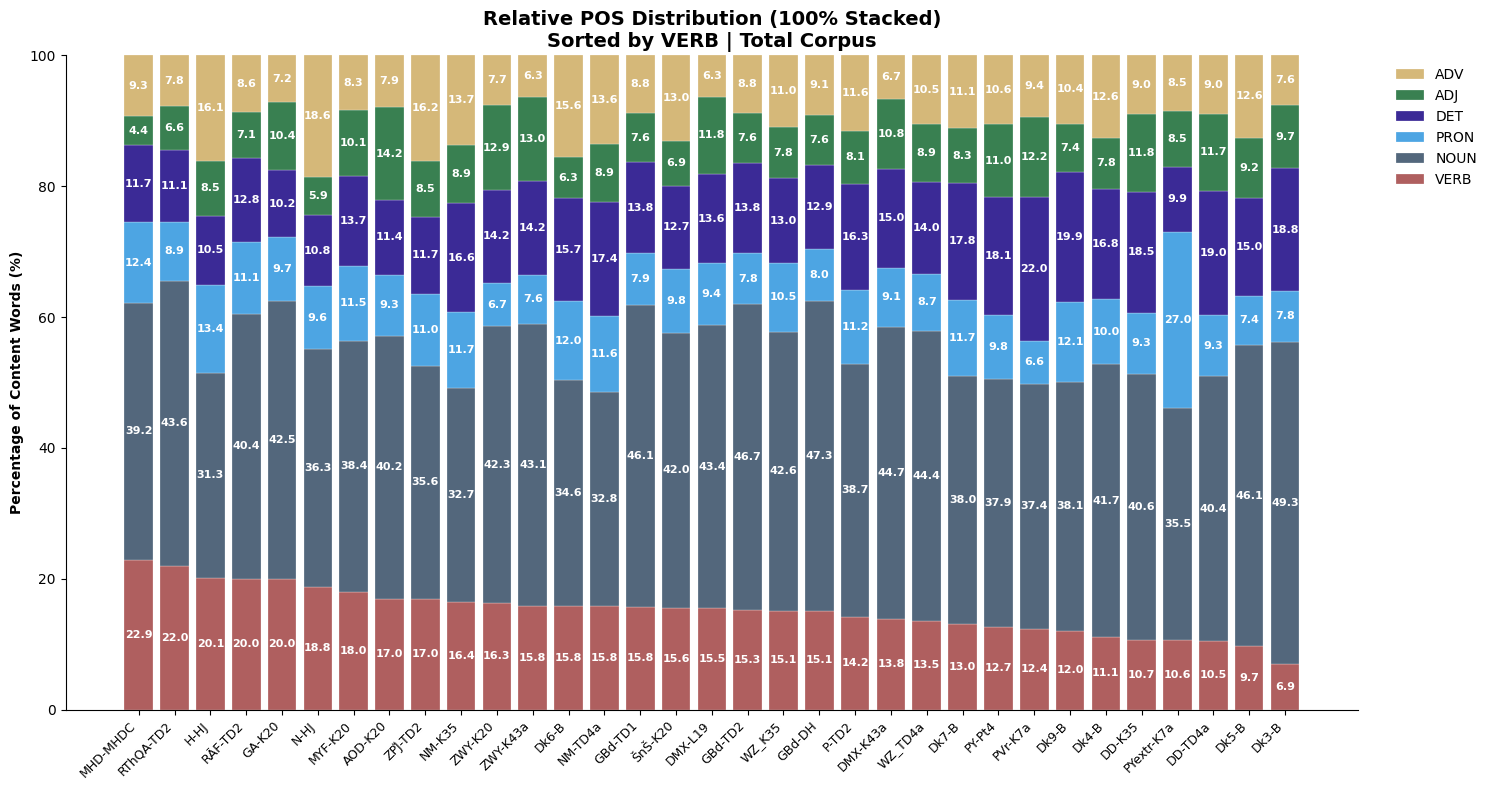

In [29]:
import pandas as pd
import matplotlib.pyplot as plt


def plot_100pct_pos(csv_file, title):
    # ======================================================
    # 1. LOAD DATA
    # ======================================================
    df = pd.read_csv(csv_file)

    # Exclude colophon texts (source_filename starts with "col")
    df = df[~df["text_id"].str.startswith("Col", na=False)]

    # ======================================================
    # 2. CONFIGURATION
    # ======================================================
    sort_standard = "VERB"
    all_categories = ["NOUN", "PRON", "DET", "ADJ", "ADV", "VERB"]

    categories = [sort_standard] + [c for c in all_categories if c != sort_standard]

    color_map = {
        "NOUN": "#40566e",
        "PRON": "#3a9be0",
        "DET":   "#25138B",
        "ADJ":   "#23723E",
        "ADV":   "#d1b16a",
        "VERB":  "#a64d4d"
    }
    plot_colors = [color_map[cat] for cat in categories]

    label_threshold = 4.0  # minimum % to show a label

    # ======================================================
    # 3. CALCULATE 100% RELATIVE SHARES
    # ======================================================
    df["content_sum"] = df[all_categories].sum(axis=1)

    for cat in all_categories:
        df[f"{cat}_pct"] = (df[cat] / df["content_sum"]) * 100

    # ======================================================
    # 4. SORT BY STANDARD CATEGORY
    # ======================================================
    df = df.sort_values(f"{sort_standard}_pct", ascending=False).reset_index(drop=True)

    # ======================================================
    # 5. PLOTTING
    # ======================================================
    x = range(len(df))
    plt.figure(figsize=(15, 8))

    current_bottom = [0.0] * len(df)

    for cat, color in zip(categories, plot_colors):
        values = df[f"{cat}_pct"].tolist()

        plt.bar(
            x,
            values,
            bottom=current_bottom,
            label=cat,
            color=color,
            alpha=0.9,
            edgecolor="white",
            linewidth=0.2
        )

        # --------------------------------------------------
        # ADD LABELS INSIDE BAR SEGMENTS
        # --------------------------------------------------
        for i, (v, btm) in enumerate(zip(values, current_bottom)):
            if v >= label_threshold:
                plt.text(
                    i,
                    btm + v / 2,
                    f"{v:.1f}",
                    ha="center",
                    va="center",
                    fontsize=8,
                    color="white",
                    fontweight="bold"
                )

        current_bottom = [b + v for b, v in zip(current_bottom, values)]

    # ======================================================
    # 6. FORMATTING
    # ======================================================
    plt.xticks(x, df["text_id"], rotation=45, ha="right", fontsize=9)
    plt.ylabel("Percentage of Content Words (%)", fontweight="bold")
    plt.ylim(0, 100)

    plt.title(
        f"Relative POS Distribution (100% Stacked)\n"
        f"Sorted by {sort_standard} | {title}",
        fontsize=14,
        fontweight="bold"
    )

    handles, labels = plt.gca().get_legend_handles_labels()
    plt.legend(
        reversed(handles),
        reversed(labels),
        loc="upper left",
        bbox_to_anchor=(1.02, 1),
        frameon=False
    )

    plt.gca().spines["top"].set_visible(False)
    plt.gca().spines["right"].set_visible(False)

    plt.tight_layout()
    plt.show()


# ======================================================
# RUN
# ======================================================
plot_100pct_pos("total_corpus_full_pos.csv", "Total Corpus")


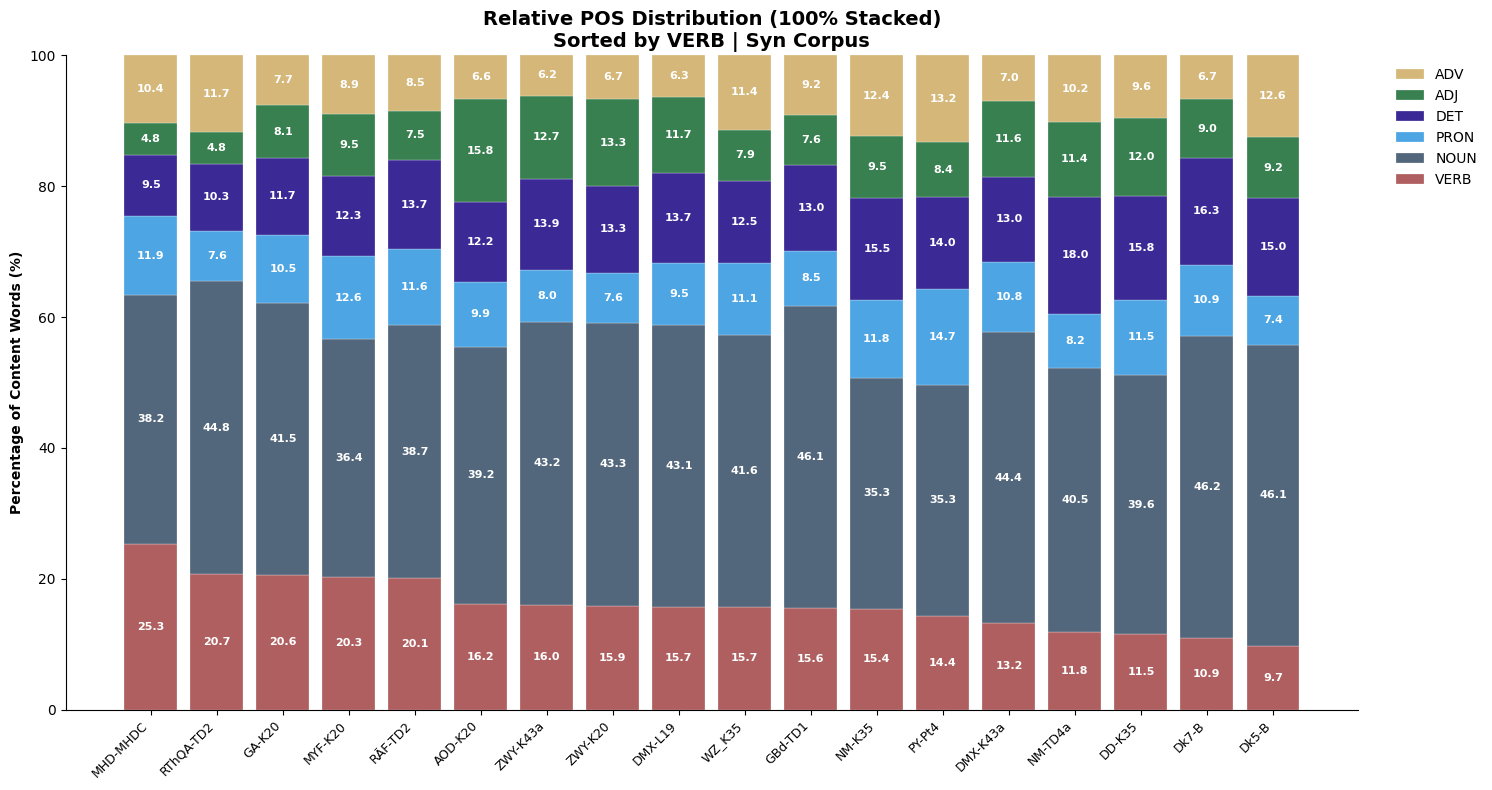

In [30]:


# ======================================================
# 3. CLEAN CSV AND PLOT
# ======================================================
def plot_100pct_pos(csv_file, title):
    df = pd.read_csv(csv_file)

    # clean filenames
    df["text_id"] = (
        df["text_id"]
        .str.replace(r"-mptf$", "", regex=True)
        .str.replace(r"\.conllu$", "", regex=True)
    )

    # filters
    df = df[~df["text_id"].str.startswith("Col", na=False)]  # exclude colophons
    df = df[df["sentences"] >= MIN_SENTENCES_SYN]             # only ≥10 sentences

    

    # Remove trailing "_mptf" and optional ".conllu" from text_id
    df["text_id"] = (
    df["text_id"]
    .str.replace(r"_mptf$", "", regex=True)      # remove trailing _mptf
    .str.replace(r"\.conllu$", "", regex=True)   # remove .conllu if present
)

    # configuration
    sort_standard = "VERB"
    all_categories = ["NOUN", "PRON", "DET", "ADJ", "ADV", "VERB"]
    categories = [sort_standard] + [c for c in all_categories if c != sort_standard]

    color_map = {
        "NOUN": "#40566e",
        "PRON": "#3a9be0",
        "DET":   "#25138B",
        "ADJ":   "#23723E",
        "ADV":   "#d1b16a",
        "VERB":  "#a64d4d"
    }
    plot_colors = [color_map[cat] for cat in categories]

    label_threshold = 4.0  # min % to show label

    # calculate percentages
    df["content_sum"] = df[all_categories].sum(axis=1)
    for cat in all_categories:
        df[f"{cat}_pct"] = (df[cat] / df["content_sum"]) * 100

    # sort
    df = df.sort_values(f"{sort_standard}_pct", ascending=False).reset_index(drop=True)

    # plot
    x = range(len(df))
    plt.figure(figsize=(15, 8))
    current_bottom = [0.0] * len(df)

    for cat, color in zip(categories, plot_colors):
        values = df[f"{cat}_pct"].tolist()
        plt.bar(x, values, bottom=current_bottom, label=cat, color=color, alpha=0.9, edgecolor="white", linewidth=0.2)

        # add in-bar labels
        for i, (v, btm) in enumerate(zip(values, current_bottom)):
            if v >= label_threshold:
                plt.text(i, btm + v / 2, f"{v:.1f}", ha="center", va="center", fontsize=8, color="white", fontweight="bold")

        current_bottom = [b + v for b, v in zip(current_bottom, values)]

    # formatting
    plt.xticks(x, df["text_id"], rotation=45, ha="right", fontsize=9)
    plt.ylabel("Percentage of Content Words (%)", fontweight="bold")
    plt.ylim(0, 100)
    plt.title(f"Relative POS Distribution (100% Stacked)\nSorted by {sort_standard} | {title}",
              fontsize=14, fontweight="bold")

    handles, labels = plt.gca().get_legend_handles_labels()
    plt.legend(reversed(handles), reversed(labels), loc="upper left", bbox_to_anchor=(1.02, 1), frameon=False)

    plt.gca().spines["top"].set_visible(False)
    plt.gca().spines["right"].set_visible(False)
    plt.tight_layout()
    plt.show()


# ======================================================
# RUN PLOT
# ======================================================
plot_100pct_pos("syn_corpus_full_pos.csv", "Syn Corpus")


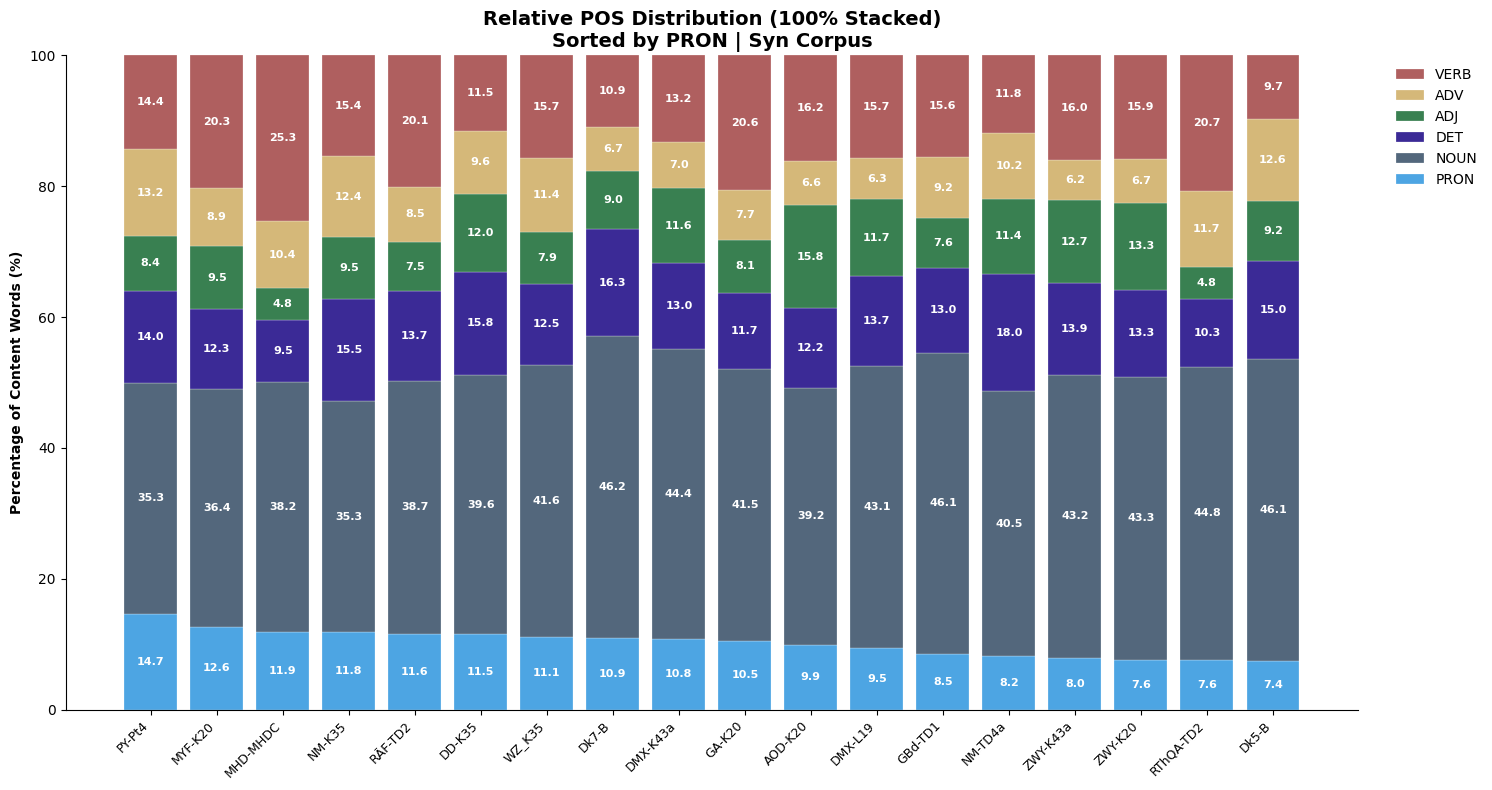

In [31]:


# ======================================================
# 3. CLEAN CSV AND PLOT
# ======================================================
def plot_100pct_pos(csv_file, title):
    df = pd.read_csv(csv_file)

    # clean filenames
    df["text_id"] = (
        df["text_id"]
        .str.replace(r"-mptf$", "", regex=True)
        .str.replace(r"\.conllu$", "", regex=True)
    )

    # filters
    df = df[~df["text_id"].str.startswith("Col", na=False)]  # exclude colophons
    df = df[df["sentences"] >= MIN_SENTENCES_SYN]             # only ≥10 sentences

    

    # Remove trailing "_mptf" and optional ".conllu" from text_id
    df["text_id"] = (
    df["text_id"]
    .str.replace(r"_mptf$", "", regex=True)      # remove trailing _mptf
    .str.replace(r"\.conllu$", "", regex=True)   # remove .conllu if present
)

    # configuration
    sort_standard = "PRON"
    all_categories = ["NOUN", "PRON", "DET", "ADJ", "ADV", "VERB"]
    categories = [sort_standard] + [c for c in all_categories if c != sort_standard]

    color_map = {
        "NOUN": "#40566e",
        "PRON": "#3a9be0",
        "DET":   "#25138B",
        "ADJ":   "#23723E",
        "ADV":   "#d1b16a",
        "VERB":  "#a64d4d"
    }
    plot_colors = [color_map[cat] for cat in categories]

    label_threshold = 4.0  # min % to show label

    # calculate percentages
    df["content_sum"] = df[all_categories].sum(axis=1)
    for cat in all_categories:
        df[f"{cat}_pct"] = (df[cat] / df["content_sum"]) * 100

    # sort
    df = df.sort_values(f"{sort_standard}_pct", ascending=False).reset_index(drop=True)

    # plot
    x = range(len(df))
    plt.figure(figsize=(15, 8))
    current_bottom = [0.0] * len(df)

    for cat, color in zip(categories, plot_colors):
        values = df[f"{cat}_pct"].tolist()
        plt.bar(x, values, bottom=current_bottom, label=cat, color=color, alpha=0.9, edgecolor="white", linewidth=0.2)

        # add in-bar labels
        for i, (v, btm) in enumerate(zip(values, current_bottom)):
            if v >= label_threshold:
                plt.text(i, btm + v / 2, f"{v:.1f}", ha="center", va="center", fontsize=8, color="white", fontweight="bold")

        current_bottom = [b + v for b, v in zip(current_bottom, values)]

    # formatting
    plt.xticks(x, df["text_id"], rotation=45, ha="right", fontsize=9)
    plt.ylabel("Percentage of Content Words (%)", fontweight="bold")
    plt.ylim(0, 100)
    plt.title(f"Relative POS Distribution (100% Stacked)\nSorted by {sort_standard} | {title}",
              fontsize=14, fontweight="bold")

    handles, labels = plt.gca().get_legend_handles_labels()
    plt.legend(reversed(handles), reversed(labels), loc="upper left", bbox_to_anchor=(1.02, 1), frameon=False)

    plt.gca().spines["top"].set_visible(False)
    plt.gca().spines["right"].set_visible(False)
    plt.tight_layout()
    plt.show()


# ======================================================
# RUN PLOT
# ======================================================
plot_100pct_pos("syn_corpus_full_pos.csv", "Syn Corpus")


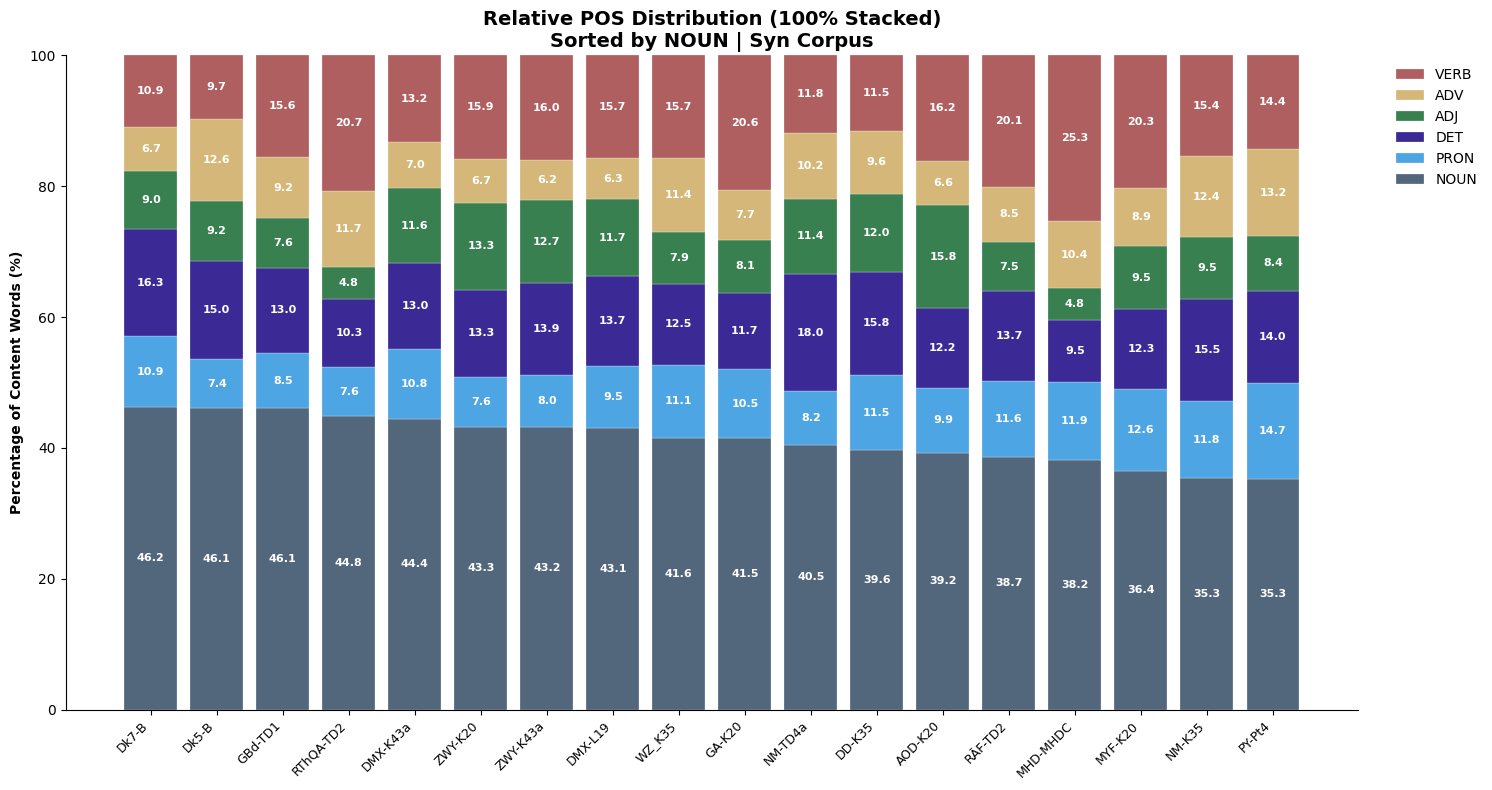

In [32]:


# ======================================================
# 3. CLEAN CSV AND PLOT
# ======================================================
def plot_100pct_pos(csv_file, title):
    df = pd.read_csv(csv_file)

    # clean filenames
    df["text_id"] = (
        df["text_id"]
        .str.replace(r"-mptf$", "", regex=True)
        .str.replace(r"\.conllu$", "", regex=True)
    )

    # filters
    df = df[~df["text_id"].str.startswith("Col", na=False)]  # exclude colophons
    df = df[df["sentences"] >= MIN_SENTENCES_SYN]             # only ≥10 sentences

    

    # Remove trailing "_mptf" and optional ".conllu" from text_id
    df["text_id"] = (
    df["text_id"]
    .str.replace(r"_mptf$", "", regex=True)      # remove trailing _mptf
    .str.replace(r"\.conllu$", "", regex=True)   # remove .conllu if present
)

    # configuration
    sort_standard = "NOUN"
    all_categories = ["NOUN", "PRON", "DET", "ADJ", "ADV", "VERB"]
    categories = [sort_standard] + [c for c in all_categories if c != sort_standard]

    color_map = {
        "NOUN": "#40566e",
        "PRON": "#3a9be0",
        "DET":   "#25138B",
        "ADJ":   "#23723E",
        "ADV":   "#d1b16a",
        "VERB":  "#a64d4d"
    }
    plot_colors = [color_map[cat] for cat in categories]

    label_threshold = 4.0  # min % to show label

    # calculate percentages
    df["content_sum"] = df[all_categories].sum(axis=1)
    for cat in all_categories:
        df[f"{cat}_pct"] = (df[cat] / df["content_sum"]) * 100

    # sort
    df = df.sort_values(f"{sort_standard}_pct", ascending=False).reset_index(drop=True)

    # plot
    x = range(len(df))
    plt.figure(figsize=(15, 8))
    current_bottom = [0.0] * len(df)

    for cat, color in zip(categories, plot_colors):
        values = df[f"{cat}_pct"].tolist()
        plt.bar(x, values, bottom=current_bottom, label=cat, color=color, alpha=0.9, edgecolor="white", linewidth=0.2)

        # add in-bar labels
        for i, (v, btm) in enumerate(zip(values, current_bottom)):
            if v >= label_threshold:
                plt.text(i, btm + v / 2, f"{v:.1f}", ha="center", va="center", fontsize=8, color="white", fontweight="bold")

        current_bottom = [b + v for b, v in zip(current_bottom, values)]

    # formatting
    plt.xticks(x, df["text_id"], rotation=45, ha="right", fontsize=9)
    plt.ylabel("Percentage of Content Words (%)", fontweight="bold")
    plt.ylim(0, 100)
    plt.title(f"Relative POS Distribution (100% Stacked)\nSorted by {sort_standard} | {title}",
              fontsize=14, fontweight="bold")

    handles, labels = plt.gca().get_legend_handles_labels()
    plt.legend(reversed(handles), reversed(labels), loc="upper left", bbox_to_anchor=(1.02, 1), frameon=False)

    plt.gca().spines["top"].set_visible(False)
    plt.gca().spines["right"].set_visible(False)
    plt.tight_layout()
    plt.show()


# ======================================================
# RUN PLOT
# ======================================================
plot_100pct_pos("syn_corpus_full_pos.csv", "Syn Corpus")


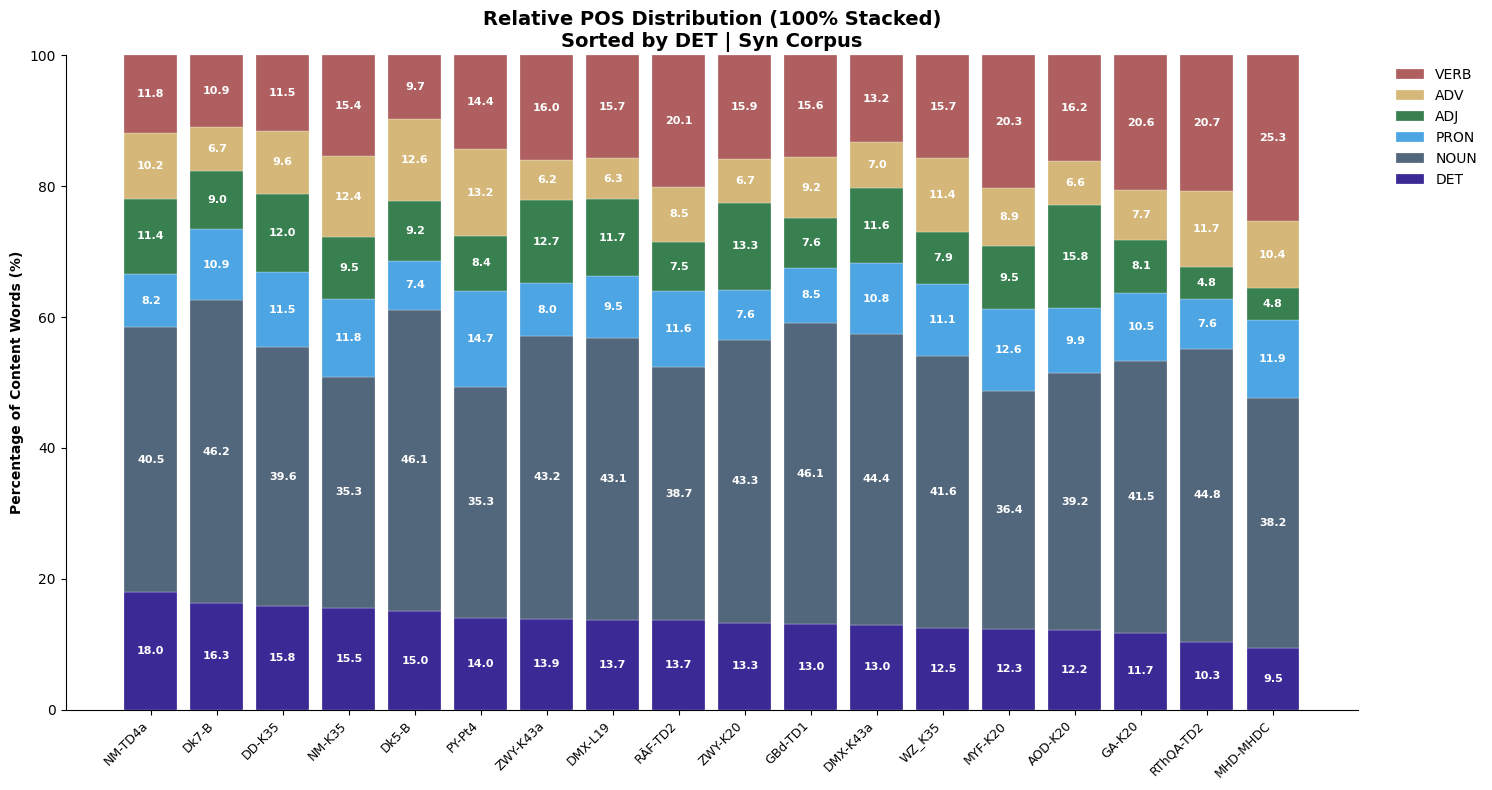

In [33]:


# ======================================================
# 3. CLEAN CSV AND PLOT
# ======================================================
def plot_100pct_pos(csv_file, title):
    df = pd.read_csv(csv_file)

    # clean filenames
    df["text_id"] = (
        df["text_id"]
        .str.replace(r"-mptf$", "", regex=True)
        .str.replace(r"\.conllu$", "", regex=True)
    )

    # filters
    df = df[~df["text_id"].str.startswith("Col", na=False)]  # exclude colophons
    df = df[df["sentences"] >= MIN_SENTENCES_SYN]             # only ≥10 sentences

    

    # Remove trailing "_mptf" and optional ".conllu" from text_id
    df["text_id"] = (
    df["text_id"]
    .str.replace(r"_mptf$", "", regex=True)      # remove trailing _mptf
    .str.replace(r"\.conllu$", "", regex=True)   # remove .conllu if present
)

    # configuration
    sort_standard = "DET"
    all_categories = ["NOUN", "PRON", "DET", "ADJ", "ADV", "VERB"]
    categories = [sort_standard] + [c for c in all_categories if c != sort_standard]

    color_map = {
        "NOUN": "#40566e",
        "PRON": "#3a9be0",
        "DET":   "#25138B",
        "ADJ":   "#23723E",
        "ADV":   "#d1b16a",
        "VERB":  "#a64d4d"
    }
    plot_colors = [color_map[cat] for cat in categories]

    label_threshold = 4.0  # min % to show label

    # calculate percentages
    df["content_sum"] = df[all_categories].sum(axis=1)
    for cat in all_categories:
        df[f"{cat}_pct"] = (df[cat] / df["content_sum"]) * 100

    # sort
    df = df.sort_values(f"{sort_standard}_pct", ascending=False).reset_index(drop=True)

    # plot
    x = range(len(df))
    plt.figure(figsize=(15, 8))
    current_bottom = [0.0] * len(df)

    for cat, color in zip(categories, plot_colors):
        values = df[f"{cat}_pct"].tolist()
        plt.bar(x, values, bottom=current_bottom, label=cat, color=color, alpha=0.9, edgecolor="white", linewidth=0.2)

        # add in-bar labels
        for i, (v, btm) in enumerate(zip(values, current_bottom)):
            if v >= label_threshold:
                plt.text(i, btm + v / 2, f"{v:.1f}", ha="center", va="center", fontsize=8, color="white", fontweight="bold")

        current_bottom = [b + v for b, v in zip(current_bottom, values)]

    # formatting
    plt.xticks(x, df["text_id"], rotation=45, ha="right", fontsize=9)
    plt.ylabel("Percentage of Content Words (%)", fontweight="bold")
    plt.ylim(0, 100)
    plt.title(f"Relative POS Distribution (100% Stacked)\nSorted by {sort_standard} | {title}",
              fontsize=14, fontweight="bold")

    handles, labels = plt.gca().get_legend_handles_labels()
    plt.legend(reversed(handles), reversed(labels), loc="upper left", bbox_to_anchor=(1.02, 1), frameon=False)

    plt.gca().spines["top"].set_visible(False)
    plt.gca().spines["right"].set_visible(False)
    plt.tight_layout()
    plt.show()


# ======================================================
# RUN PLOT
# ======================================================
plot_100pct_pos("syn_corpus_full_pos.csv", "Syn Corpus")


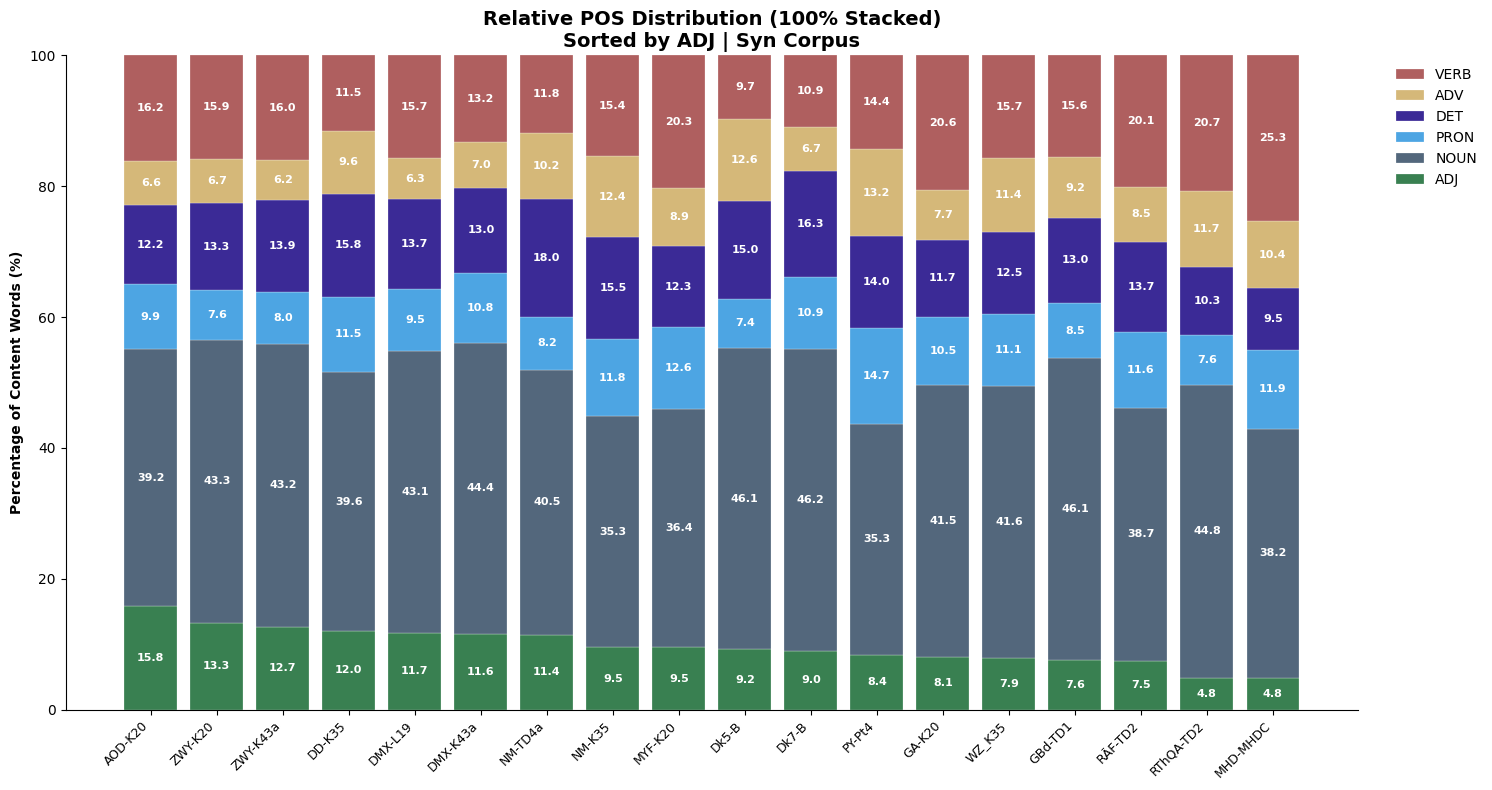

In [34]:


# ======================================================
# 3. CLEAN CSV AND PLOT
# ======================================================
def plot_100pct_pos(csv_file, title):
    df = pd.read_csv(csv_file)

    # clean filenames
    df["text_id"] = (
        df["text_id"]
        .str.replace(r"-mptf$", "", regex=True)
        .str.replace(r"\.conllu$", "", regex=True)
    )

    # filters
    df = df[~df["text_id"].str.startswith("Col", na=False)]  # exclude colophons
    df = df[df["sentences"] >= MIN_SENTENCES_SYN]             # only ≥10 sentences

    

    # Remove trailing "_mptf" and optional ".conllu" from text_id
    df["text_id"] = (
    df["text_id"]
    .str.replace(r"_mptf$", "", regex=True)      # remove trailing _mptf
    .str.replace(r"\.conllu$", "", regex=True)   # remove .conllu if present
)

    # configuration
    sort_standard = "ADJ"
    all_categories = ["NOUN", "PRON", "DET", "ADJ", "ADV", "VERB"]
    categories = [sort_standard] + [c for c in all_categories if c != sort_standard]

    color_map = {
        "NOUN": "#40566e",
        "PRON": "#3a9be0",
        "DET":   "#25138B",
        "ADJ":   "#23723E",
        "ADV":   "#d1b16a",
        "VERB":  "#a64d4d"
    }
    plot_colors = [color_map[cat] for cat in categories]

    label_threshold = 4.0  # min % to show label

    # calculate percentages
    df["content_sum"] = df[all_categories].sum(axis=1)
    for cat in all_categories:
        df[f"{cat}_pct"] = (df[cat] / df["content_sum"]) * 100

    # sort
    df = df.sort_values(f"{sort_standard}_pct", ascending=False).reset_index(drop=True)

    # plot
    x = range(len(df))
    plt.figure(figsize=(15, 8))
    current_bottom = [0.0] * len(df)

    for cat, color in zip(categories, plot_colors):
        values = df[f"{cat}_pct"].tolist()
        plt.bar(x, values, bottom=current_bottom, label=cat, color=color, alpha=0.9, edgecolor="white", linewidth=0.2)

        # add in-bar labels
        for i, (v, btm) in enumerate(zip(values, current_bottom)):
            if v >= label_threshold:
                plt.text(i, btm + v / 2, f"{v:.1f}", ha="center", va="center", fontsize=8, color="white", fontweight="bold")

        current_bottom = [b + v for b, v in zip(current_bottom, values)]

    # formatting
    plt.xticks(x, df["text_id"], rotation=45, ha="right", fontsize=9)
    plt.ylabel("Percentage of Content Words (%)", fontweight="bold")
    plt.ylim(0, 100)
    plt.title(f"Relative POS Distribution (100% Stacked)\nSorted by {sort_standard} | {title}",
              fontsize=14, fontweight="bold")

    handles, labels = plt.gca().get_legend_handles_labels()
    plt.legend(reversed(handles), reversed(labels), loc="upper left", bbox_to_anchor=(1.02, 1), frameon=False)

    plt.gca().spines["top"].set_visible(False)
    plt.gca().spines["right"].set_visible(False)
    plt.tight_layout()
    plt.show()


# ======================================================
# RUN PLOT
# ======================================================
plot_100pct_pos("syn_corpus_full_pos.csv", "Syn Corpus")


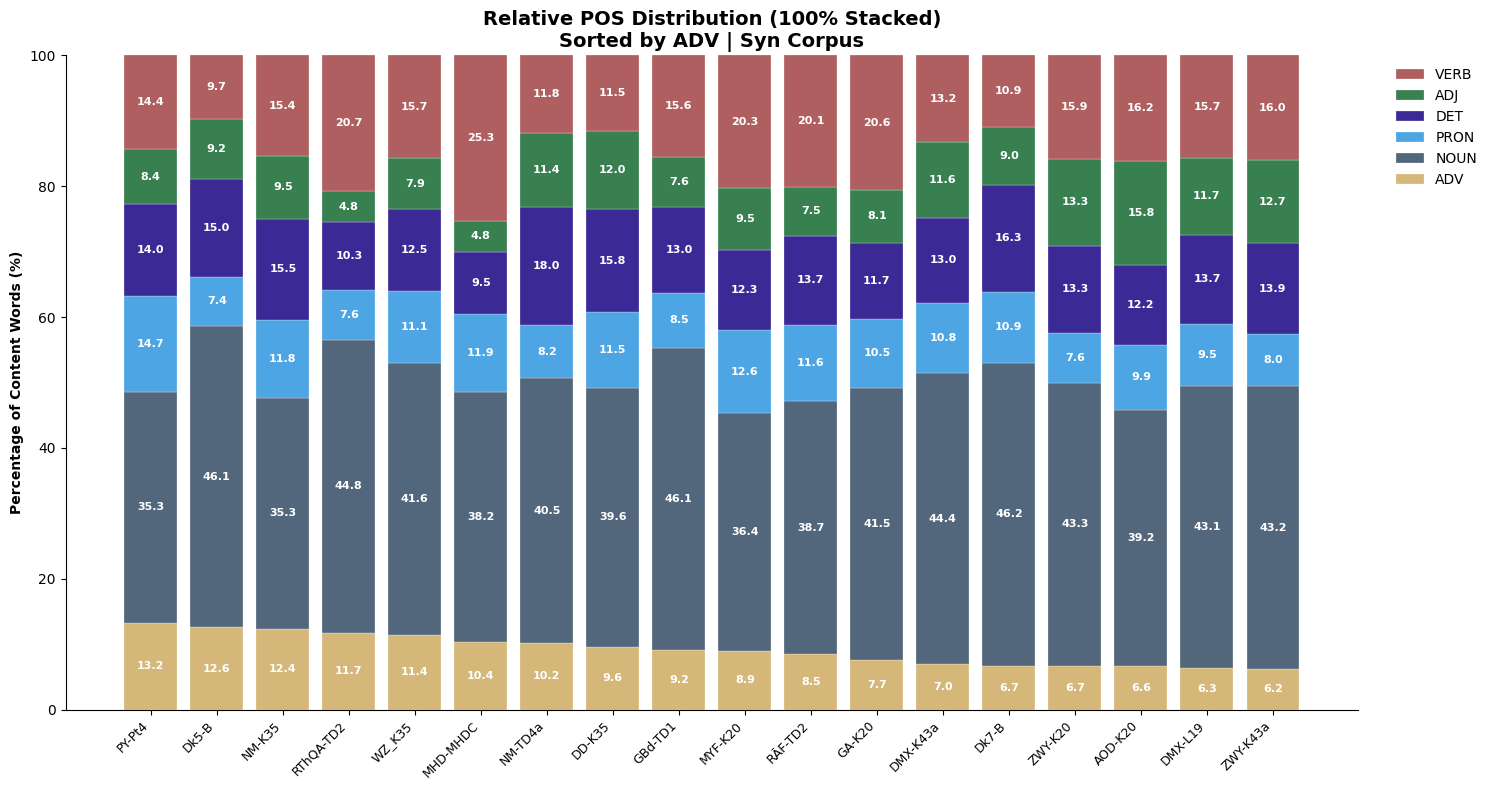

In [35]:


# ======================================================
# 3. CLEAN CSV AND PLOT
# ======================================================
def plot_100pct_pos(csv_file, title):
    df = pd.read_csv(csv_file)

    # clean filenames
    df["text_id"] = (
        df["text_id"]
        .str.replace(r"-mptf$", "", regex=True)
        .str.replace(r"\.conllu$", "", regex=True)
    )

    # filters
    df = df[~df["text_id"].str.startswith("Col", na=False)]  # exclude colophons
    df = df[df["sentences"] >= MIN_SENTENCES_SYN]             # only ≥10 sentences

    

    # Remove trailing "_mptf" and optional ".conllu" from text_id
    df["text_id"] = (
    df["text_id"]
    .str.replace(r"_mptf$", "", regex=True)      # remove trailing _mptf
    .str.replace(r"\.conllu$", "", regex=True)   # remove .conllu if present
)

    # configuration
    sort_standard = "ADV"
    all_categories = ["NOUN", "PRON", "DET", "ADJ", "ADV", "VERB"]
    categories = [sort_standard] + [c for c in all_categories if c != sort_standard]

    color_map = {
        "NOUN": "#40566e",
        "PRON": "#3a9be0",
        "DET":   "#25138B",
        "ADJ":   "#23723E",
        "ADV":   "#d1b16a",
        "VERB":  "#a64d4d"
    }
    plot_colors = [color_map[cat] for cat in categories]

    label_threshold = 4.0  # min % to show label

    # calculate percentages
    df["content_sum"] = df[all_categories].sum(axis=1)
    for cat in all_categories:
        df[f"{cat}_pct"] = (df[cat] / df["content_sum"]) * 100

    # sort
    df = df.sort_values(f"{sort_standard}_pct", ascending=False).reset_index(drop=True)

    # plot
    x = range(len(df))
    plt.figure(figsize=(15, 8))
    current_bottom = [0.0] * len(df)

    for cat, color in zip(categories, plot_colors):
        values = df[f"{cat}_pct"].tolist()
        plt.bar(x, values, bottom=current_bottom, label=cat, color=color, alpha=0.9, edgecolor="white", linewidth=0.2)

        # add in-bar labels
        for i, (v, btm) in enumerate(zip(values, current_bottom)):
            if v >= label_threshold:
                plt.text(i, btm + v / 2, f"{v:.1f}", ha="center", va="center", fontsize=8, color="white", fontweight="bold")

        current_bottom = [b + v for b, v in zip(current_bottom, values)]

    # formatting
    plt.xticks(x, df["text_id"], rotation=45, ha="right", fontsize=9)
    plt.ylabel("Percentage of Content Words (%)", fontweight="bold")
    plt.ylim(0, 100)
    plt.title(f"Relative POS Distribution (100% Stacked)\nSorted by {sort_standard} | {title}",
              fontsize=14, fontweight="bold")

    handles, labels = plt.gca().get_legend_handles_labels()
    plt.legend(reversed(handles), reversed(labels), loc="upper left", bbox_to_anchor=(1.02, 1), frameon=False)

    plt.gca().spines["top"].set_visible(False)
    plt.gca().spines["right"].set_visible(False)
    plt.tight_layout()
    plt.show()


# ======================================================
# RUN PLOT
# ======================================================
plot_100pct_pos("syn_corpus_full_pos.csv", "Syn Corpus")


In [36]:
# excluding texts with less than 10 sentences for this specific query
from collections import defaultdict, Counter
import csv


def export_full_pos_to_csv(corpus, output_filename):
    # --------------------------------------------------
    # storage
    # --------------------------------------------------
    text_stats = defaultdict(Counter)
    sentence_counts = Counter()

    # keeps track of all ADV feature-value columns
    adv_feat_keys = set()

    # --------------------------------------------------
    # collect statistics
    # --------------------------------------------------
    for sentence in corpus:
        text_id = sentence.metadata.get("source_filename", "unknown")

        # count sentences per text
        sentence_counts[text_id] += 1

        for token in sentence.get_tokens():
            upos = token.upos

            # total tokens (base for density)
            if upos not in ("PUNCT", "X"):
                text_stats[text_id]["total_tokens"] += 1

            # POS categories
            if upos in {"NOUN", "PROPN"}:
                text_stats[text_id]["NOUN"] += 1

            elif upos == "PRON":
                text_stats[text_id]["PRON"] += 1

            elif upos == "ADJ":
                text_stats[text_id]["ADJ"] += 1

            elif upos == "ADV":
                text_stats[text_id]["ADV"] += 1

                # ------------------------------------------
                # ADV feature-value classification
                # ------------------------------------------
                feats = token.feats or {}
                for feat_key, feat_val in feats.items():
                    # handle multi-valued features (e.g. Degree=Cmp,Pos)
                    for val in str(feat_val).split(","):
                        col_name = f"ADV_{feat_key}_{val}"
                        text_stats[text_id][col_name] += 1
                        adv_feat_keys.add(col_name)

            elif upos == "VERB":
                text_stats[text_id]["VERB"] += 1

            elif upos == "DET":
                text_stats[text_id]["DET"] += 1

    # --------------------------------------------------
    # write CSV
    # --------------------------------------------------
    adv_feat_columns = sorted(adv_feat_keys)

    with open(output_filename, "w", encoding="utf-8", newline="") as f:
        writer = csv.writer(f)

        writer.writerow([
            "text_id",
            "sentences",
            "total_tokens",
            "NOUN",
            "PRON",
            "ADJ",
            "ADV",
            "VERB",
            "DET",
            *adv_feat_columns
        ])

        for tid in sorted(text_stats):
            s = text_stats[tid]
            writer.writerow([
                tid,
                sentence_counts[tid],
                s["total_tokens"],
                s["NOUN"],
                s["PRON"],
                s["ADJ"],
                s["ADV"],
                s["VERB"],
                s["DET"],
                *[s.get(col, 0) for col in adv_feat_columns]
            ])


# --------------------------------------------------
# run
# --------------------------------------------------
export_full_pos_to_csv(my_corpus, "total_corpus_full_pos.csv")
export_full_pos_to_csv(syntactically_annotated_corpus, "syn_corpus_full_pos.csv")

print("✔ CSV files exported successfully.")


✔ CSV files exported successfully.


In [37]:
# excluding texts with less than 10 sentences for this specific query
from collections import defaultdict, Counter
import csv


def export_full_pos_to_csv(corpus, output_filename):
    # --------------------------------------------------
    # storage
    # --------------------------------------------------
    text_stats = defaultdict(Counter)
    sentence_counts = Counter()

    # keeps track of all ADV feature-value columns
    adv_feat_keys = set()

    # --------------------------------------------------
    # collect statistics
    # --------------------------------------------------
    for sentence in corpus:
        text_id = sentence.metadata.get("source_filename", "unknown")

        # count sentences per text
        sentence_counts[text_id] += 1

        for token in sentence.get_tokens():
            upos = token.upos

            # total tokens (base for density)
            if upos not in ("PUNCT", "X"):
                text_stats[text_id]["total_tokens"] += 1

            # POS categories
            if upos in {"NOUN", "PROPN"}:
                text_stats[text_id]["NOUN"] += 1

            elif upos == "PRON":
                text_stats[text_id]["PRON"] += 1

            elif upos == "ADJ":
                text_stats[text_id]["ADJ"] += 1

            elif upos == "ADV":
                text_stats[text_id]["ADV"] += 1

                # ------------------------------------------
                # only consider AdvType features
                # ------------------------------------------
                feats = token.feats or {}
                adv_type_val = feats.get("AdvType")
                if adv_type_val:
                    for val in str(adv_type_val).split(","):  # handle multi-valued
                        col_name = f"ADV_AdvType_{val}"
                        text_stats[text_id][col_name] += 1
                        adv_feat_keys.add(col_name)

            elif upos == "VERB":
                text_stats[text_id]["VERB"] += 1

            elif upos == "DET":
                text_stats[text_id]["DET"] += 1

    # --------------------------------------------------
    # write CSV
    # --------------------------------------------------
    adv_feat_columns = sorted(adv_feat_keys)

    with open(output_filename, "w", encoding="utf-8", newline="") as f:
        writer = csv.writer(f)

        writer.writerow([
            "text_id",
            "sentences",
            "total_tokens",
            "NOUN",
            "PRON",
            "ADJ",
            "ADV",
            "VERB",
            "DET",
            *adv_feat_columns
        ])

        for tid in sorted(text_stats):
            s = text_stats[tid]
            writer.writerow([
                tid,
                sentence_counts[tid],
                s["total_tokens"],
                s["NOUN"],
                s["PRON"],
                s["ADJ"],
                s["ADV"],
                s["VERB"],
                s["DET"],
                *[s.get(col, 0) for col in adv_feat_columns]
            ])


# --------------------------------------------------
# run
# --------------------------------------------------
export_full_pos_to_csv(my_corpus, "total_corpus_full_pos.csv")
export_full_pos_to_csv(syntactically_annotated_corpus, "syn_corpus_full_pos.csv")

print("✔ CSV files exported successfully.")



✔ CSV files exported successfully.


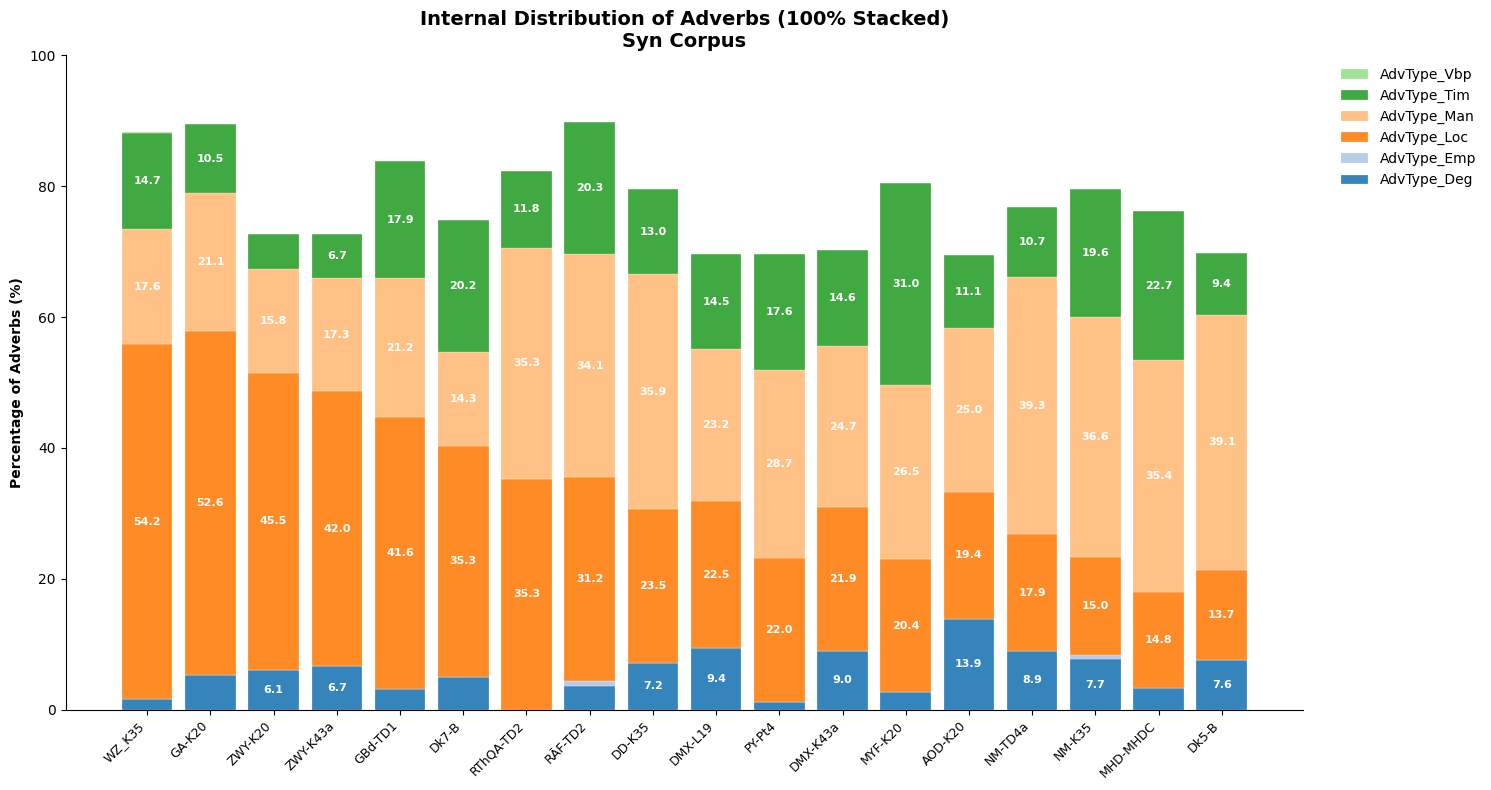

In [38]:
import pandas as pd
import matplotlib.pyplot as plt

MIN_SENTENCES_SYN = 10


# ======================================================
# ADV FEATURE 100% STACKED PLOT
# ======================================================
def plot_100pct_adv_features(csv_file, title):
    df = pd.read_csv(csv_file)

    # --------------------------------------
    # clean filenames
    # --------------------------------------
    df["text_id"] = (
        df["text_id"]
        .str.replace(r"_mptf$", "", regex=True)
        .str.replace(r"\.conllu$", "", regex=True)
    )

    # --------------------------------------
    # filters
    # --------------------------------------
    df = df[~df["text_id"].str.startswith("Col", na=False)]
    df = df[df["sentences"] >= MIN_SENTENCES_SYN]

    # --------------------------------------
    # select ADV feature columns
    # --------------------------------------
    adv_cols = [c for c in df.columns if c.startswith("ADV_")]

    if not adv_cols:
        raise ValueError("No ADV feature columns found in CSV.")

    # remove texts with zero adverbs
    df = df[df["ADV"] > 0].copy()

    # --------------------------------------
    # normalize to 100% of adverbs
    # --------------------------------------
    for col in adv_cols:
        df[f"{col}_pct"] = (df[col] / df["ADV"]) * 100

    pct_cols = [f"{c}_pct" for c in adv_cols]

    # --------------------------------------
    # sort by most frequent ADV feature
    # --------------------------------------
    sort_col = max(pct_cols, key=lambda c: df[c].mean())
    df = df.sort_values(sort_col, ascending=False).reset_index(drop=True)

    # --------------------------------------
    # plotting
    # --------------------------------------
    x = range(len(df))
    plt.figure(figsize=(15, 8))
    current_bottom = [0.0] * len(df)

    # simple color cycle (feature-heavy plots get messy fast)
    colors = plt.cm.tab20.colors

    label_threshold = 6.0  # % threshold for in-bar labels

    for i, col in enumerate(pct_cols):
        values = df[col].tolist()
        label = col.replace("ADV_", "").replace("_pct", "")

        plt.bar(
            x,
            values,
            bottom=current_bottom,
            label=label,
            color=colors[i % len(colors)],
            alpha=0.9,
            edgecolor="white",
            linewidth=0.2
        )

        # in-bar labels
        for j, (v, btm) in enumerate(zip(values, current_bottom)):
            if v >= label_threshold:
                plt.text(
                    j,
                    btm + v / 2,
                    f"{v:.1f}",
                    ha="center",
                    va="center",
                    fontsize=8,
                    color="white",
                    fontweight="bold"
                )

        current_bottom = [b + v for b, v in zip(current_bottom, values)]

    # --------------------------------------
    # formatting
    # --------------------------------------
    plt.xticks(x, df["text_id"], rotation=45, ha="right", fontsize=9)
    plt.ylabel("Percentage of Adverbs (%)", fontweight="bold")
    plt.ylim(0, 100)
    plt.title(
        f"Internal Distribution of Adverbs (100% Stacked)\n{title}",
        fontsize=14,
        fontweight="bold"
    )

    handles, labels = plt.gca().get_legend_handles_labels()
    plt.legend(
        reversed(handles),
        reversed(labels),
        loc="upper left",
        bbox_to_anchor=(1.02, 1),
        frameon=False
    )

    plt.gca().spines["top"].set_visible(False)
    plt.gca().spines["right"].set_visible(False)
    plt.tight_layout()
    plt.show()
    
plot_100pct_adv_features(
    "syn_corpus_full_pos.csv",
    "Syn Corpus"
)
